# Lecture 6: Data Visualization

In this notebook we will learn how to generate basic plots with Python.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Types of Plots



### Plotting Functions

We start how to generate a simple plot of the function
$$ f(x) = \cos(x) + \sin(x) $$


Text(0, 0.5, 'y')

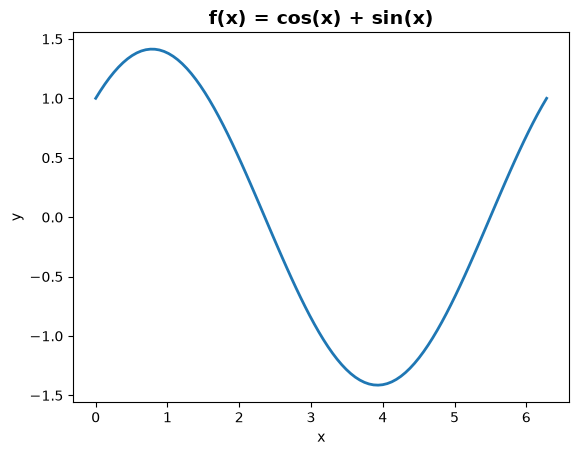

In [12]:
## create x values
f_x = np.linspace(0,2*np.pi, 100)

# create y values
f_y = np.cos(f_x) + np.sin(f_x)

## generate plot
plt.plot(f_x,f_y,'-',linewidth=2)

## add labels
plt.title("f(x) = cos(x) + sin(x)", size = 14, weight = 'bold')
plt.xlabel("x")
plt.ylabel("y")

Next we have the model 
$$P(t)=P_{\mathrm{final}}(1-e^{-t/\tau})$$

with $P_{\mathrm{final}}=10$ kPa and two time constants, $\tau=0.25$ s and $\tau=0.75$ s. 

A smaller time constant produces a faster response. At $t=\tau$, the model reaches approximately 63.2% of its final value.

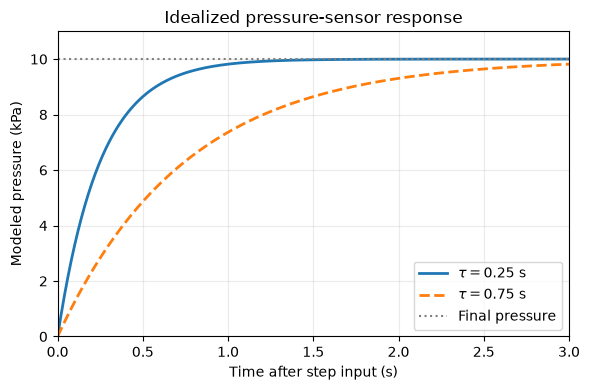

In [13]:
# Function plot: idealized first-order pressure-sensor response to a step input.
# P(t) = P_final * (1 - exp(-t/tau)); this is a model, not sampled measurements.
model_time_s = np.linspace(0, 3, 301)
final_pressure_kpa = 10.0
fast_tau_s = 0.25
slow_tau_s = 0.75
fast_pressure_kpa = final_pressure_kpa * (1 - np.exp(-model_time_s / fast_tau_s))
slow_pressure_kpa = final_pressure_kpa * (1 - np.exp(-model_time_s / slow_tau_s))


fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(model_time_s, fast_pressure_kpa, label=r"$\tau = 0.25$ s", linewidth=2)
ax.plot(model_time_s, slow_pressure_kpa, label=r"$\tau = 0.75$ s", linestyle="--", linewidth=2)
ax.axhline(final_pressure_kpa, color="gray", linestyle=":", label="Final pressure")
ax.set(xlabel="Time after step input (s)", ylabel="Modeled pressure (kPa)",
       title="Idealized pressure-sensor response", xlim=(0, 3), ylim=(0, 11))
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()



**Question**

What happens if we change the number of time values (i.e. `model_time_s`)?



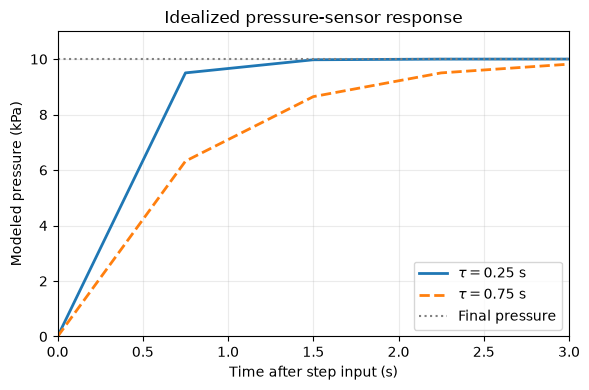

In [14]:
model_time_s = np.linspace(0, 3, 5)
final_pressure_kpa = 10.0
fast_tau_s = 0.25
slow_tau_s = 0.75
fast_pressure_kpa = final_pressure_kpa * (1 - np.exp(-model_time_s / fast_tau_s))
slow_pressure_kpa = final_pressure_kpa * (1 - np.exp(-model_time_s / slow_tau_s))


fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(model_time_s, fast_pressure_kpa, label=r"$\tau = 0.25$ s", linewidth=2)
ax.plot(model_time_s, slow_pressure_kpa, label=r"$\tau = 0.75$ s", linestyle="--", linewidth=2)
ax.axhline(final_pressure_kpa, color="gray", linestyle=":", label="Final pressure")
ax.set(xlabel="Time after step input (s)", ylabel="Modeled pressure (kPa)",
       title="Idealized pressure-sensor response", xlim=(0, 3), ylim=(0, 11))
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

### Time Series

Time Series plots display observations $(t_i,y_i)$, where $t_i$ is the time of measurement and $y_i$ is the measured quantity.

Points are ordered by time and often connected with line segments. Note that the actual time coordinates preserve unequal sampling intervals; connecting lines do not establish what occurred between measurements.

Time series plots are useful when examining how a quantity changes over time. For example, temperature during cooling or heart rate during exercise and recovery.



The example below lets us examine how two benchtop cooling conditions change temperature over time.


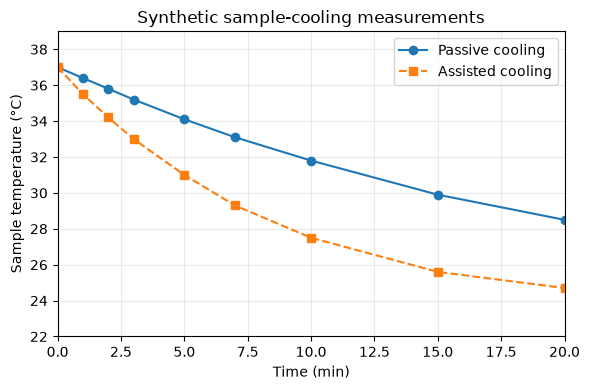

In [18]:
# Time series: paired measurements at ordered but unevenly spaced times.
# Two runs of a benchtop sample-cooling demonstration, not patient data.

cooling_time_min = np.array([0, 1, 2, 3, 5, 7, 10, 15, 20], dtype=float)

passive_temp_c = np.array([37, 36.4, 35.8, 35.2, 34.1, 33.1, 31.8, 29.9, 28.5])
assisted_temp_c = np.array([37, 35.5, 34.2, 33.0, 31.0, 29.3, 27.5, 25.6, 24.7])


fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(cooling_time_min, passive_temp_c, "o-", label="Passive cooling")
ax.plot(cooling_time_min, assisted_temp_c, "s--", label="Assisted cooling")
ax.set(xlabel="Time (min)", ylabel="Sample temperature (°C)",
       title="Synthetic sample-cooling measurements", xlim=(0, 20), ylim=(22, 39))
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


Each marker is one invented recorded measurement. Both runs use the same measurement times.

Note: Lines connect observations in time order and do not establish or estimate values between samples. This is merely a means to better visualize trends in the plot. If you want to get an estimate of values in between data points, you must use a process called _interpolation_ to construct a function/curve that can properly estimate values between observed data points.

**Question**

What would be lost by using `range(9)` for the x axis?


### Scatter Plot

Displays paired observations as points $(x_i,y_i)$, where each point represents two measurements from the same sample or experimental condition. Neither variable must be time, and points are generally not connected by a line.

Scatter Plots are useful when exploring the relationship between two numerical variables—for example, pump speed versus flow rate. Patterns can reveal increasing or decreasing relationships, curvature, or departures from a trend.


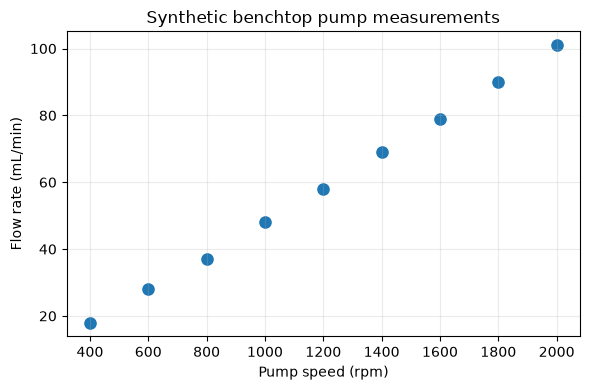

In [2]:
# Scatter: independent benchtop pump settings, one paired observation per setting.
# Deliberately unsorted to show why connecting acquisition-order points misleads.
pump_speed_rpm = np.array([1200, 400, 1600, 800, 2000, 600, 1400, 1000, 1800], dtype=float)
flow_ml_min = np.array([58, 18, 79, 37, 101, 28, 69, 48, 90], dtype=float)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(pump_speed_rpm, flow_ml_min, s=65, color="tab:blue")
ax.set(xlabel="Pump speed (rpm)", ylabel="Flow rate (mL/min)",
       title="Synthetic benchtop pump measurements")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Spatial heatmap

Represents a scalar field $z=f(x,y)$, or measurements $z_{ij}$ on a spatial grid, by mapping numerical values to colors. The axes locate positions in space, while a colorbar identifies the values and units encoded by color.

Helpful when examining where a quantity is high or low across a region—for example, temperature across a tissue phantom or pressure across a contact surface.


### Example: tissue-phantom temperature

Tissue phantoms are specially engineered artificial or tissue-derived models designed to mimic the physical, optical, or acoustic properties of human organs and tissues. They are used in device calibration, training, and research.


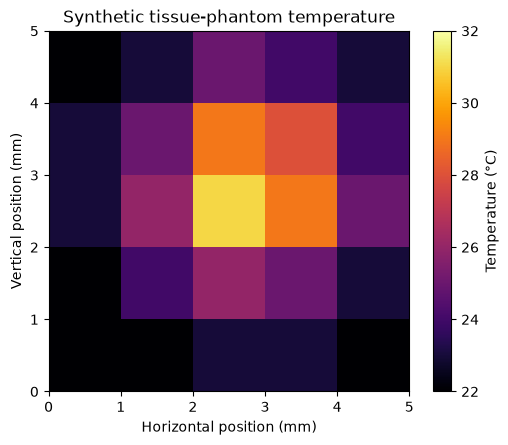

In [19]:
# Spatial heatmap: synthetic temperature measurements at pixel centers on a
# 5 x 5 mm tissue phantom. Columns increase in x; rows increase in y.
# Each value represents a 1 x 1 mm pixel; bottom-left center is (0.5, 0.5) mm.
x_centers_mm = np.arange(0.5, 5.0, 1.0)
y_centers_mm = np.arange(0.5, 5.0, 1.0)
phantom_temp_c = np.array([
    [22, 22, 23, 23, 22],
    [22, 24, 26, 25, 23],
    [23, 26, 31, 29, 25],
    [23, 25, 29, 28, 24],
    [22, 23, 25, 24, 23],
], dtype=float)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(phantom_temp_c, origin="lower", extent=(0, 5, 0, 5),
               cmap="inferno", vmin=22, vmax=32, interpolation="nearest", aspect="equal")
ax.set(xlabel="Horizontal position (mm)", ylabel="Vertical position (mm)",
       title="Synthetic tissue-phantom temperature")
fig.colorbar(im, ax=ax, label="Temperature (°C)")
fig.tight_layout()
plt.show()

Note that this is a spatial image, not a correlation matrix. Each matrix element (i.e. square in the grid) represents a 1 × 1 mm pixel on a 5 × 5 mm phantom. Columns correspond to x; rows correspond to y increasing upward. Pixel centers run from 0.5 to 4.5 mm on each axis.

**Questions:** 

Where is the warmest region in a small tissue phantom?

How would omitting `origin="lower"` change orientation? 

Why are position units on the axes and temperature units on the colorbar? 

Does smooth color interpolation create new measured information?

## Subplots

We reuse the cooling data to demonstrate two panels. The upper panel shows the measured temperatures; the lower panel shows **passive minus assisted temperature** at each matched time. The difference has units of °C. 

Sharing the x axis aligns the observations without requiring a second vertical axis on the same panel.

<!-- **Ask:** Is the lower panel an additional measurement or a calculation? What does a positive difference mean? Why is subtraction valid only for aligned observations? -->

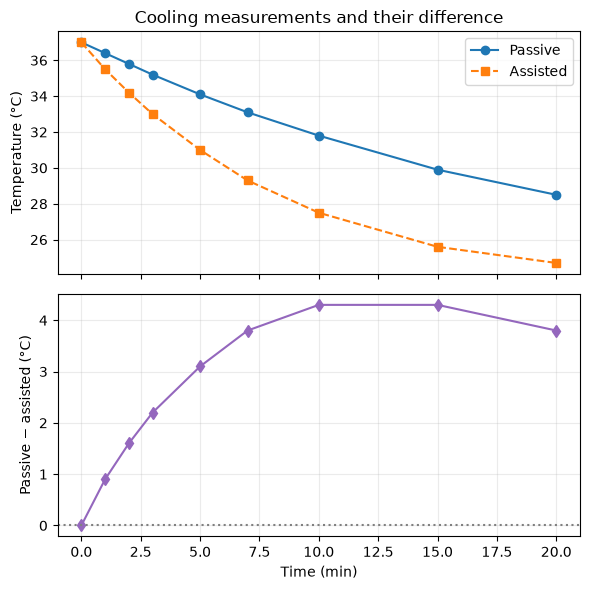

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(6, 6), sharex=True)
axes[0].plot(cooling_time_min, passive_temp_c, "o-", label="Passive")
axes[0].plot(cooling_time_min, assisted_temp_c, "s--", label="Assisted")
axes[0].set_ylabel("Temperature (°C)")
axes[0].set_title("Cooling measurements and their difference")
axes[0].legend()
axes[1].plot(cooling_time_min, passive_temp_c - assisted_temp_c, "d-", color="tab:purple")
axes[1].axhline(0, color="gray", linestyle=":")
axes[1].set(xlabel="Time (min)", ylabel="Passive − assisted (°C)")
for ax in axes:
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## Options for Plots

This next section covers some of the options that are available when creating plots.

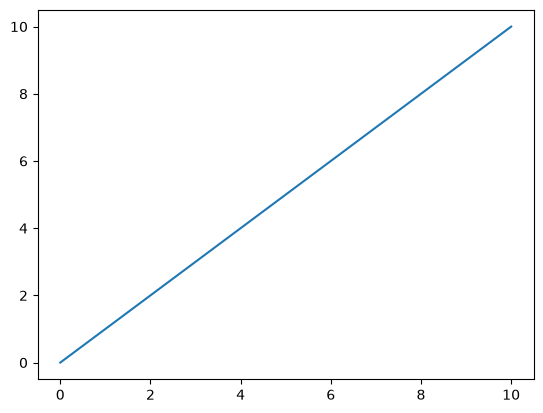

In [14]:
x = np.linspace(0,10,5)
y = x

y1 = x+1
y2 = x+2
y3 = x+3
y4 = x+4
y5 = x+5
y6 = x+6
y7 = x+7
y8 = x+8
y9 = x+9
y10 = x+10
y11 = x+11
y12 = x+12

plt.figure()
plt.plot(x,y)
plt.savefig('basicPlot.pdf')

Specifying title, axes, and legend

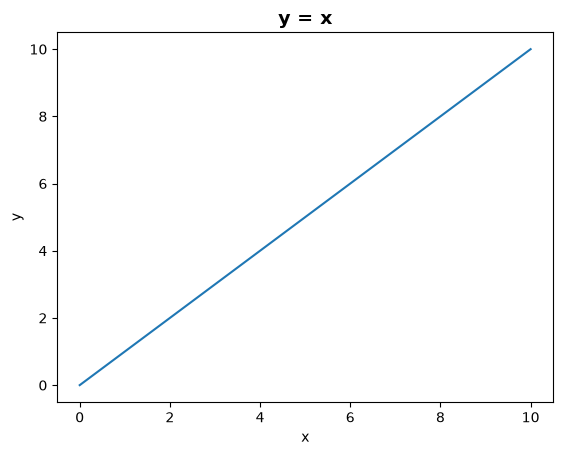

In [15]:
x = np.linspace(0,10,5)
y = x 

plt.figure()
plt.plot(x,y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('y = x', size=14, weight='bold')
plt.savefig('basicPlotTitled.pdf')

### Line Colors

### Declaring Line Colors

Text(0.5, 1.0, 'Default Defined Line Colors')

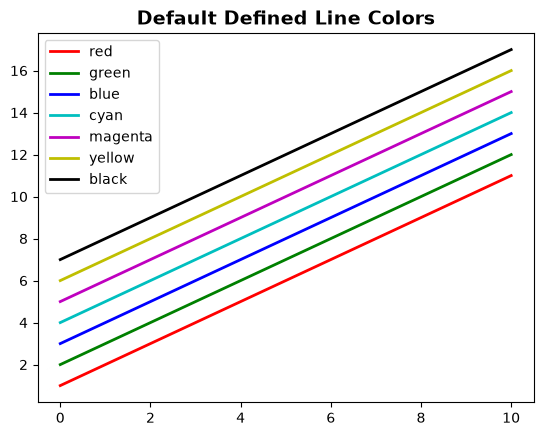

In [18]:
plt.figure()
cmap = plt.get_cmap("tab10")
plt.plot(x,y1,color='r',linewidth=2)
plt.plot(x,y2,color='g',linewidth=2)
plt.plot(x,y3,color='b',linewidth=2)
plt.plot(x,y4,color='c',linewidth=2)
plt.plot(x,y5,color='m',linewidth=2)
plt.plot(x,y6,color='y',linewidth=2)
plt.plot(x,y7,color='k',linewidth=2)
plt.legend(('red','green','blue','cyan','magenta','yellow','black'))
plt.title('Default Defined Line Colors',size = 14, weight = 'bold')
# plt.savefig('specifiedPlotColors.eps')

You don't need to declare line colors when plotting multiple lines. Python by default will cycle through 10 different colors as demonstrated in the figure below.

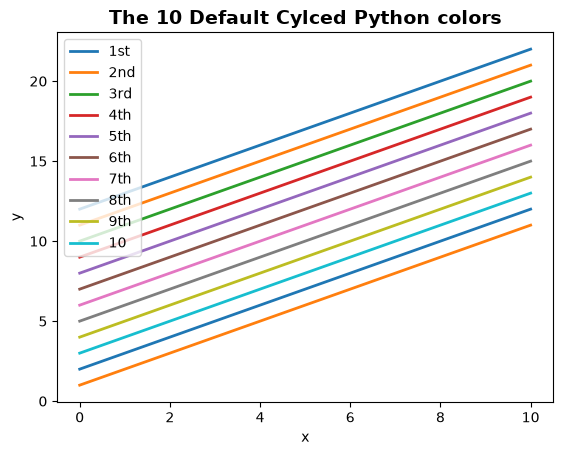

In [16]:
plt.figure()
plt.plot(x,y12,'-',linewidth=2)
plt.plot(x,y11,'-',linewidth=2)
plt.plot(x,y10,'-',linewidth=2)
plt.plot(x,y9,'-',linewidth=2)
plt.plot(x,y8,'-',linewidth=2)
plt.plot(x,y7,'-',linewidth=2)
plt.plot(x,y6,'-',linewidth=2)
plt.plot(x,y5,'-',linewidth=2)
plt.plot(x,y4,'-',linewidth=2)
plt.plot(x,y3,'-',linewidth=2)
plt.plot(x,y2,'-',linewidth=2)
plt.plot(x,y1,'-',linewidth=2)

plt.title("The 10 Default Cylced Python colors", size = 14, weight = 'bold')
plt.xlabel("x")
plt.ylabel("y")
plt.legend(('1st','2nd','3rd','4th','5th','6th','7th','8th','9th','10'))
# plt.savefig("plot_colors.eps")

### Markers

When you want to see the actual points being plotted, we show these by specifying a marker. The different types are demonstrated in the figure below.


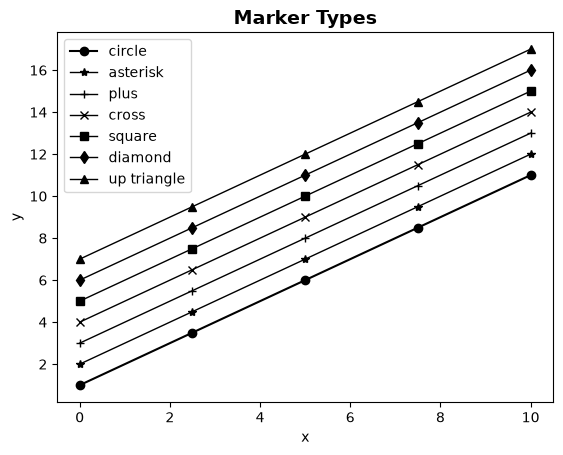

In [19]:
plt.figure()
plt.plot(x,y1,color='k', marker='o')
plt.plot(x,y2,color='k', marker='*',linewidth=1)
plt.plot(x,y3,color='k', marker='+',linewidth=1)
plt.plot(x,y4,color='k', marker='x',linewidth=1)
plt.plot(x,y5,color='k', marker='s', linewidth=1)
plt.plot(x,y6,color='k', marker='d',linewidth=1)
plt.plot(x,y7,color='k', marker='^',linewidth=1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Marker Types',size=14, weight = 'bold')
plt.legend(('circle','asterisk','plus','cross','square','diamond','up triangle'))
# plt.savefig('markeStyles.eps')

#### Marker Options

Changing color, size, outline color, etc

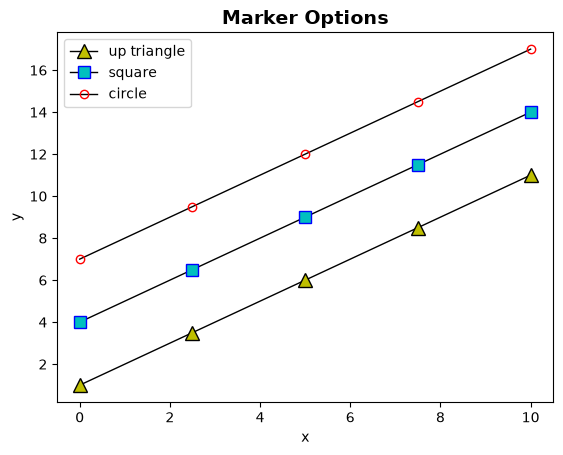

In [21]:
plt.figure()
plt.plot(x,y1,color='k', marker='^',linewidth=1, markersize = 10, markeredgecolor='k', markerfacecolor='y')
plt.plot(x,y4,color='k', marker='s',linewidth=1, markersize = 8, markeredgecolor='b', markerfacecolor='c')
plt.plot(x,y7,color='k', marker='o',linewidth=1, markeredgecolor='r', fillstyle='none')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Marker Options',size=14, weight = 'bold')
plt.legend(('up triangle','square', 'circle'))
# plt.savefig('markerOptions.eps')


### Subplots



Text(0.5, 0.98, 'Subplots')

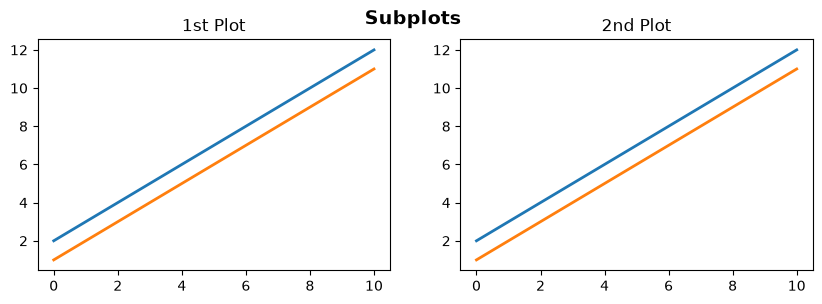

In [26]:

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10, 3))
### second subplot
ax1.plot(x,y2,'-',linewidth=2)
ax1.plot(x,y1,'-',linewidth=2)
ax1.set_title('1st Plot')

### second subplot
ax2.plot(x,y2,'-',linewidth=2)
ax2.plot(x,y1,'-',linewidth=2)
ax2.set_title('2nd Plot')

fig.suptitle('Subplots',size=14,weight='bold')